### Graph Attention Networks

In [7]:
import torch
torchversion = torch.__version__

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-{torchversion}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-{torchversion}.html
!pip install torch-geometric

import numpy as np
np.random.seed(0)

# Visualization
import networkx as nx
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [3]:
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root=".", name="CiteSeer")

data = dataset[0]

print(f'Dataset: {dataset}')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of nodes: {data.x.shape[0]}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

print(f'\nGraph:')
print(f'Edges are directed: {data.is_directed()}')
print(f'Graph has isolated nodes: {data.has_isolated_nodes()}')
print(f'Graph has loops: {data.has_self_loops()}')

Dataset: CiteSeer()
Number of graphs: 1
Number of nodes: 3327
Number of features: 3703
Number of classes: 6

Graph:
Edges are directed: False
Graph has isolated nodes: True
Graph has loops: False


<BarContainer object of 32 artists>

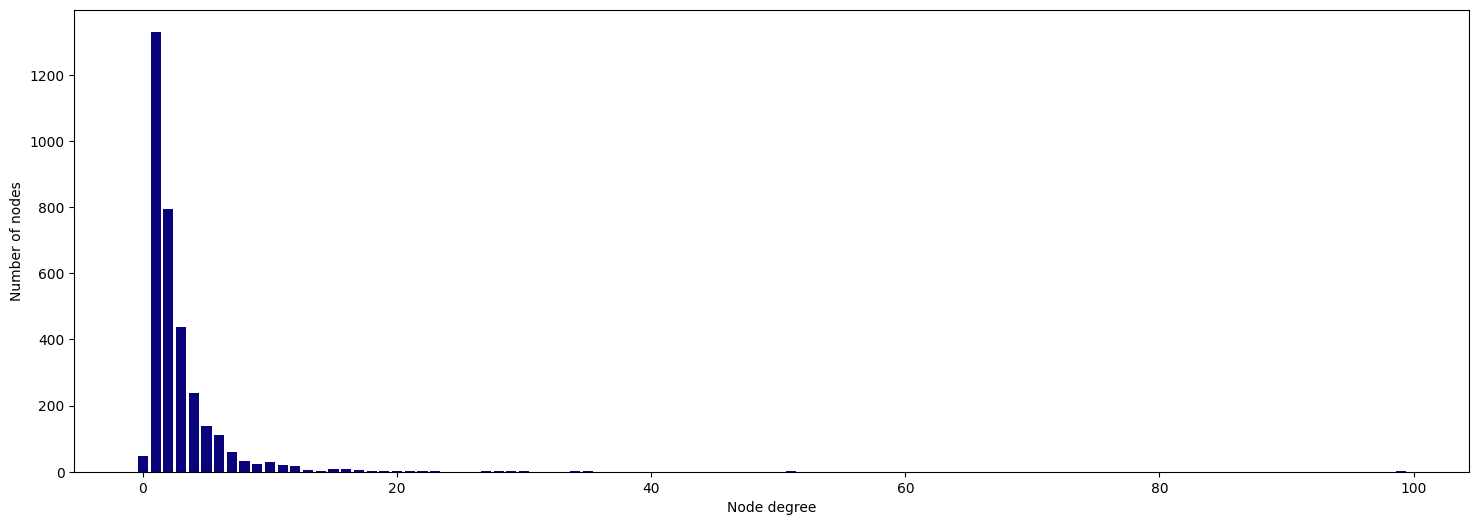

In [8]:
from torch_geometric.utils import degree
from collections import Counter

# Get a list of degrees for each node
degrees = degree(data.edge_index[0]).numpy()

# Counte the number of nodes for each degree
numbers = Counter(degrees)

fig, ax = plt.subplots(figsize=(18, 6))
ax.set_xlabel('Node degree')
ax.set_ylabel('Number of nodes')
plt.bar(numbers.keys(),
        numbers.values(),
        color='#0A047A')

In [18]:
import torch.nn.functional as F
from torch.nn import Linear, Dropout
from torch_geometric.nn import GCNConv, GATv2Conv

class GCN(torch.nn.Module):
    """Graph Convolutional Network"""
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.gcn1 = GCNConv(dim_in, dim_h)
        self.gcn2 = GCNConv(dim_h, dim_out)
        self.optimizer = torch.optim.Adam(self.parameters(), lr=0.01, weight_decay=5e-4)

    def forward(self, x, edge_index):
        h = F.dropout(x, p=0.5, training=self.training)
        h = self.gcn1(h, edge_index).relu()
        
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.gcn2(h, edge_index)

        return h, F.log_softmax(h, dim=1)
    
class GAT(torch.nn.Module):
    """Graph Attention Network"""
    def __init__(self, dim_in, dim_h, dim_out, heads=8):
        super().__init__()
        self.gat1 = GATv2Conv(dim_in, dim_h, heads=heads)
        self.gat2 = GATv2Conv(dim_h*heads, dim_out, heads=1)
        self.optimizer = torch.optim.Adam(self.parameters(), lr=0.005, weight_decay=5e-4)

    def forward(self, x, edge_index):
        h = F.dropout(x, p=0.6, training=self.training)
        h = self.gat1(h, edge_index)
        h = F.elu(h)
        
        h = F.dropout(h, p=0.6, training=self.training)
        h = self.gat2(h, edge_index)
        return h, F.log_softmax(h, dim=1)
    
def accuracy (pred_y, y):
    return ((pred_y == y).sum() / len(y)).item()

def train(model, data):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = model.optimizer
    epochs = 200

    model.train()
    for epoch in range(epochs+1):
        # Training
        optimizer.zero_grad()

        _, out = model(data.x, data.edge_index)

        loss = criterion(out[data.train_mask], data.y[data.train_mask])

        acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])

        loss.backward()

        optimizer.step()

        # Validation
        val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
        val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])

        # Print metrics every 10 epochs
        if(epoch % 10 == 0):
            print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: '
                  f'{acc*100:>6.2f}% | Val Loss: {val_loss:.2f} | '
                  f'Val Acc: {val_acc*100:.2f}%')
            
    return model

@torch.no_grad()
def test(model, data):
    """Evaluate the model on test set and print the accuracy score."""
    model.eval()
    _, out = model(data.x, data.edge_index)
    acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
    return acc

In [12]:
%%time
# Create GCN model
gcn = GCN(dataset.num_features, 16, dataset.num_classes)
print(gcn)

# Train and test
train(gcn, data)
acc = test(gcn, data)
print(f'\nGCN test accuracy: {acc*100:.2f}%\n')

GCN(
  (gcn1): GCNConv(3703, 16)
  (gcn2): GCNConv(16, 6)
)
Epoch   0 | Train Loss: 1.798 | Train Acc:  18.33% | Val Loss: 1.81 | Val Acc: 12.20%
Epoch  10 | Train Loss: 0.528 | Train Acc:  90.83% | Val Loss: 1.28 | Val Acc: 54.80%
Epoch  20 | Train Loss: 0.210 | Train Acc:  93.33% | Val Loss: 1.43 | Val Acc: 58.00%
Epoch  30 | Train Loss: 0.111 | Train Acc:  96.67% | Val Loss: 1.55 | Val Acc: 56.60%
Epoch  40 | Train Loss: 0.071 | Train Acc:  98.33% | Val Loss: 1.50 | Val Acc: 55.00%
Epoch  50 | Train Loss: 0.055 | Train Acc:  99.17% | Val Loss: 1.49 | Val Acc: 58.40%
Epoch  60 | Train Loss: 0.040 | Train Acc: 100.00% | Val Loss: 1.47 | Val Acc: 59.00%
Epoch  70 | Train Loss: 0.059 | Train Acc:  98.33% | Val Loss: 1.52 | Val Acc: 57.60%
Epoch  80 | Train Loss: 0.050 | Train Acc:  98.33% | Val Loss: 1.66 | Val Acc: 55.40%
Epoch  90 | Train Loss: 0.043 | Train Acc:  99.17% | Val Loss: 1.59 | Val Acc: 57.80%
Epoch 100 | Train Loss: 0.052 | Train Acc:  98.33% | Val Loss: 1.49 | Val Acc: 5

In [19]:
%%time
# Create GAT model
gat = GAT(dataset.num_features, 8, dataset.num_classes)
print(gat)

# Train and test
train(gat, data)
acc = test(gat, data)
print(f'\nGAT test accuracy: {acc*100:.2f}%\n')

GAT(
  (gat1): GATv2Conv(3703, 8, heads=8)
  (gat2): GATv2Conv(64, 6, heads=1)
)
Epoch   0 | Train Loss: 1.825 | Train Acc:  10.83% | Val Loss: 1.81 | Val Acc: 17.20%
Epoch  10 | Train Loss: 0.265 | Train Acc:  95.83% | Val Loss: 1.13 | Val Acc: 63.80%
Epoch  20 | Train Loss: 0.066 | Train Acc:  98.33% | Val Loss: 1.27 | Val Acc: 60.40%
Epoch  30 | Train Loss: 0.050 | Train Acc:  98.33% | Val Loss: 1.35 | Val Acc: 61.20%
Epoch  40 | Train Loss: 0.028 | Train Acc: 100.00% | Val Loss: 1.47 | Val Acc: 62.80%
Epoch  50 | Train Loss: 0.019 | Train Acc: 100.00% | Val Loss: 1.40 | Val Acc: 62.80%
Epoch  60 | Train Loss: 0.040 | Train Acc:  99.17% | Val Loss: 1.28 | Val Acc: 63.40%
Epoch  70 | Train Loss: 0.018 | Train Acc: 100.00% | Val Loss: 1.45 | Val Acc: 61.60%
Epoch  80 | Train Loss: 0.033 | Train Acc:  99.17% | Val Loss: 1.31 | Val Acc: 62.20%
Epoch  90 | Train Loss: 0.045 | Train Acc:  99.17% | Val Loss: 1.43 | Val Acc: 60.20%
Epoch 100 | Train Loss: 0.019 | Train Acc: 100.00% | Val Lo